import packages:

In [193]:
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

use pandas to load the dataset:

In [194]:
import pandas as pd
df = pd.read_csv('listings.csv')

Display the first 5 rows of the dataset:

In [195]:
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2992450,https://www.airbnb.com/rooms/2992450,20250105040826,2025-01-05,previous scrape,Luxury 2 bedroom apartment,The apartment is located in a quiet neighborho...,NaN,https://a0.muscache.com/pictures/44627226/0e72...,4621559,...,4.56,3.22,3.67,NaN,f,1,1,0,0,0.07
1,3820211,https://www.airbnb.com/rooms/3820211,20250105040826,2025-01-05,city scrape,Restored Precinct in Center Sq. w/Parking,"Cozy, cool little 1BR Apt in the heart Albany'...","Great restaurants, architecture, walking, peop...",https://a0.muscache.com/pictures/prohost-api/H...,19648678,...,4.81,4.82,4.78,NaN,f,4,4,0,0,2.42
2,5651579,https://www.airbnb.com/rooms/5651579,20250105040826,2025-01-05,city scrape,Large studio apt by Capital Center & ESP@,"Spacious studio with hardwood floors, fully eq...",The neighborhood is very eclectic. We have a v...,https://a0.muscache.com/pictures/b3fc42f3-6e5e...,29288920,...,4.87,4.76,4.64,NaN,f,2,1,1,0,3.14
3,6623339,https://www.airbnb.com/rooms/6623339,20250105040826,2025-01-05,city scrape,Center Sq. Loft in Converted Precinct w/ Parking,Large renovated 1 bedroom apartment in convert...,"Located in Albany's finest urban neighborhood,...",https://a0.muscache.com/pictures/prohost-api/H...,19648678,...,4.70,4.80,4.72,NaN,f,4,4,0,0,2.82
4,9005989,https://www.airbnb.com/rooms/9005989,20250105040826,2025-01-05,city scrape,"Studio in The heart of Center SQ, in Albany NY",(21 years of age or older ONLY) NON- SMOKING.....,"There are many shops, restaurants, bars, museu...",https://a0.muscache.com/pictures/d242a77e-437c...,17766924,...,4.93,4.87,4.78,NaN,f,1,1,0,0,5.90


Describe the dataset's statistical properties (mean, median, standard deviation).

In [196]:
df.describe()

,id,scrape_id,host_id,host_listings_count,host_total_listings_count,neighbourhood_group_cleansed,latitude,longitude,accommodates,bathrooms,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,4.290000e+02,4.290000e+02,4.290000e+02,429.000000,429.000000,0.0,429.000000,429.000000,429.000000,395.000000,...,374.000000,374.000000,374.000000,374.000000,0.0,429.000000,429.000000,429.000000,429.000000,374.000000
mean,6.691283e+17,2.025011e+13,2.367239e+08,29.067599,48.065268,NaN,42.657644,-73.776211,3.494172,1.202532,...,4.862112,4.870214,4.675508,4.729572,NaN,6.174825,4.379953,1.792541,0.002331,2.090936
std,4.945228e+17,0.000000e+00,1.909060e+08,149.370181,286.038942,NaN,0.009597,0.018662,2.566515,0.587081,...,0.278906,0.253123,0.367092,0.388818,NaN,6.409304,6.005657,3.636695,0.048280,2.079791
min,2.992450e+06,2.025011e+13,6.576000e+04,1.000000,1.000000,NaN,42.630660,-73.876490,1.000000,0.000000,...,2.000000,3.000000,3.000000,1.000000,NaN,1.000000,0.000000,0.000000,0.000000,0.050000
25%,5.157990e+07,2.025011e+13,4.762598e+07,2.000000,2.000000,NaN,42.652220,-73.788280,2.000000,1.000000,...,4.850000,4.860000,4.520000,4.670000,NaN,1.000000,1.000000,0.000000,0.000000,0.550000
50%,8.038680e+17,2.025011e+13,1.923130e+08,4.000000,5.000000,NaN,42.656790,-73.772870,2.000000,1.000000,...,4.945000,4.960000,4.810000,4.830000,NaN,3.000000,2.000000,0.000000,0.000000,1.405000
75%,1.102984e+18,2.025011e+13,3.920749e+08,12.000000,15.000000,NaN,42.662610,-73.763250,4.000000,1.000000,...,5.000000,5.000000,4.930000,4.940000,NaN,8.000000,5.000000,1.000000,0.000000,3.017500
max,1.325491e+18,2.025011e+13,6.671428e+08,1212.000000,2405.000000,NaN,42.714900,-73.738250,16.000000,7.000000,...,5.000000,5.000000,5.000000,5.000000,NaN,23.000000,23.000000,13.000000,1.000000,11.270000


Check for any missing values and print their column names and the corresponding number of missing values. Then present the data missing rate using a bar chart.

In [197]:
#Check for any missing values and print their column names and the corresponding number of missing values.
missing_stats = pd.DataFrame({
    'number of missing values': df.isnull().sum(),
    'missing rate (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_cols = missing_stats[missing_stats['number of missing values'] > 0].sort_values('number of missing values', ascending=False)
missing_cols

,number of missing values,missing rate (%)
neighbourhood_group_cleansed,429,100.00
calendar_updated,429,100.00
license,429,100.00
neighborhood_overview,216,50.35
neighbourhood,216,50.35
host_about,195,45.45
host_location,86,20.05
host_neighbourhood,66,15.38
review_scores_rating,55,12.82
last_review,55,12.82


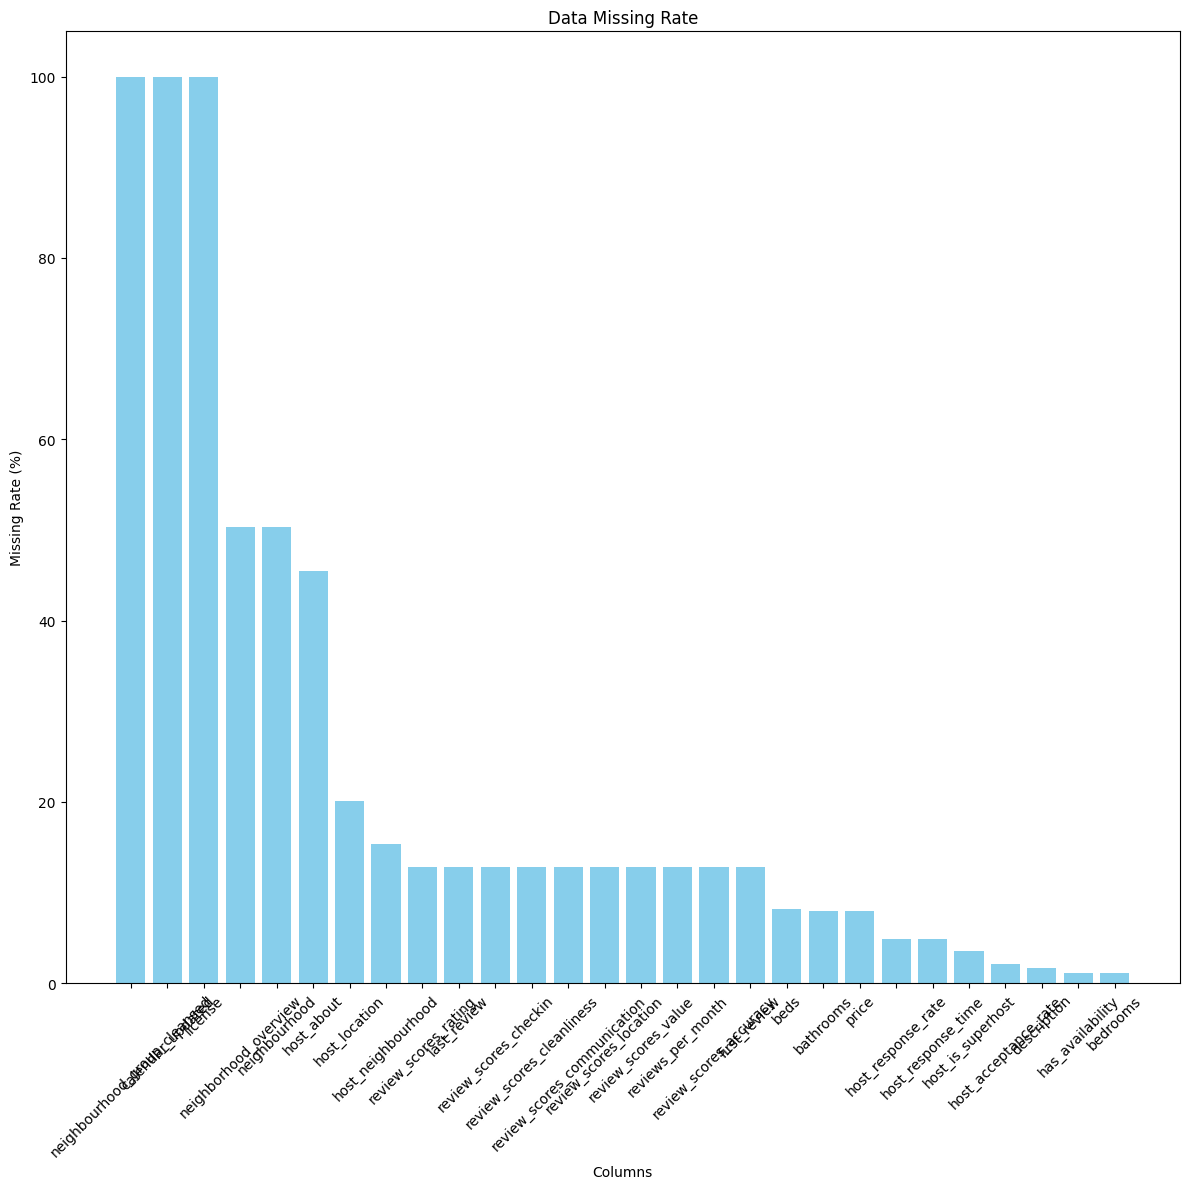

In [198]:
#Then present the data missing rate using a bar chart.
plt.figure(figsize=(12, 12))
plt.bar(missing_cols.index, missing_cols['missing rate (%)'], color='skyblue')
plt.xlabel('Columns')
plt.ylabel('Missing Rate (%)')
plt.title('Data Missing Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Handle missing values if there are any:

In [199]:
#Fill in the missing values of the 'price' with the mean value.
df_filled = df.copy()
def clean_price(text):
    if pd.isna(text):
        return text
    cleaned = str(text).replace('$', '').replace(',', '').strip()
    return cleaned if cleaned else np.nan
df_filled['price'] = df_filled['price'].apply(clean_price)
df_filled['price'] = pd.to_numeric(df_filled['price'], errors='coerce')
df_filled['price'] = df_filled['price'].fillna(df_filled['price'].mean())

#Fill in missing values of 'description' with 'Not Provided'.
df_filled['description'] = df_filled['description'].fillna('Not Provided')

#Fill in the missing value of 'host_response_time' with mode value.
df_filled['host_response_time'] = df_filled['host_response_time'].fillna(df_filled['host_response_time'].mode()[0])

#Fill the missing values in the column 'host_is_superhost' and convert it into one-hot encoding.
df_filled['host_is_superhost'] = df_filled['host_is_superhost'].fillna('false')
df_filled = pd.get_dummies(df_filled, columns=['host_is_superhost'], prefix='host_is_superhost')

#Print the number of remaining missing values for each column.
print(df_filled.isnull().sum())

id                                              0
listing_url                                     0
scrape_id                                       0
last_scraped                                    0
source                                          0
                                               ..
calculated_host_listings_count_shared_rooms     0
reviews_per_month                              55
host_is_superhost_f                             0
host_is_superhost_false                         0
host_is_superhost_t                             0
Length: 77, dtype: int64


Remove duplicates and handle any inconsistencies in the data. Print the number of duplicate data.

In [200]:
df_cleaned = df_filled.drop_duplicates()
print(f"Number of duplicate rows: {len(df_filled) - len(df_cleaned)}")

Number of duplicate rows: 0


Convert 'neighbourhood' to one-hot encoding and print 'neighbourhood'.

In [201]:
#Convert 'neighbourhood' to one-hot encoding and print 'neighbourhood'.
df_cleaned = pd.get_dummies(df_cleaned, columns=['neighbourhood'], prefix='neighbourhood')
print(df_cleaned.columns[df_cleaned.columns.str.startswith('neighbourhood_')])

Index(['neighbourhood_cleansed', 'neighbourhood_group_cleansed',
       'neighbourhood_Neighborhood highlights'],
      dtype='object')


Visualize the distribution of ‘price’ using histplot.

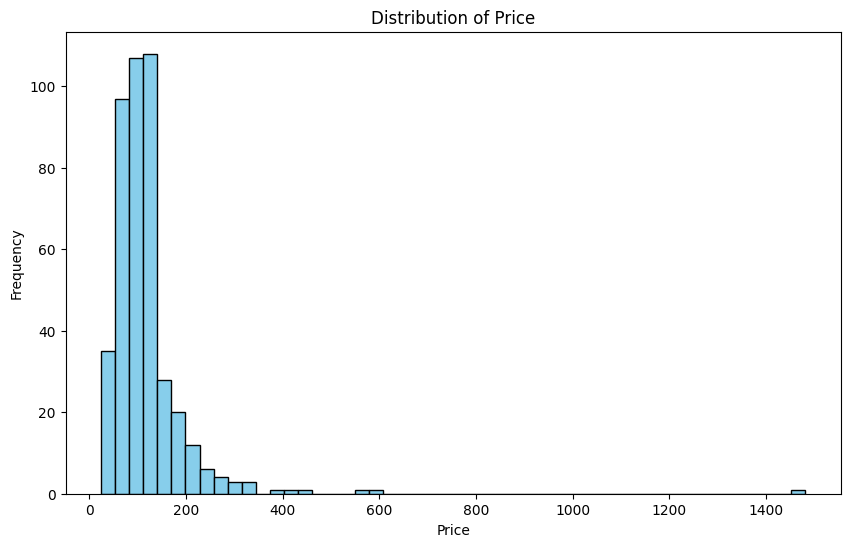

In [202]:
#Visualize the distribution of ‘price’ using histplot.
plt.figure(figsize=(10, 6))
plt.hist(df_cleaned['price'], bins=50, color='skyblue', edgecolor='black')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Distribution of Price')
plt.show()

Use the Interquartile Range (IQR) method to remove or cap extreme outliers.

In [203]:
#Use the Interquartile Range (IQR) method to remove or cap extreme outliers.
Q1 = df_cleaned['price'].quantile(0.25)
Q3 = df_cleaned['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_cleaned = df_cleaned[(df_cleaned['price'] >= lower_bound) & (df_cleaned['price'] <= upper_bound)]

Visualize the ‘price’ distribution after IQR processing using hisplot and briefly analyze the differences between the two distributions.

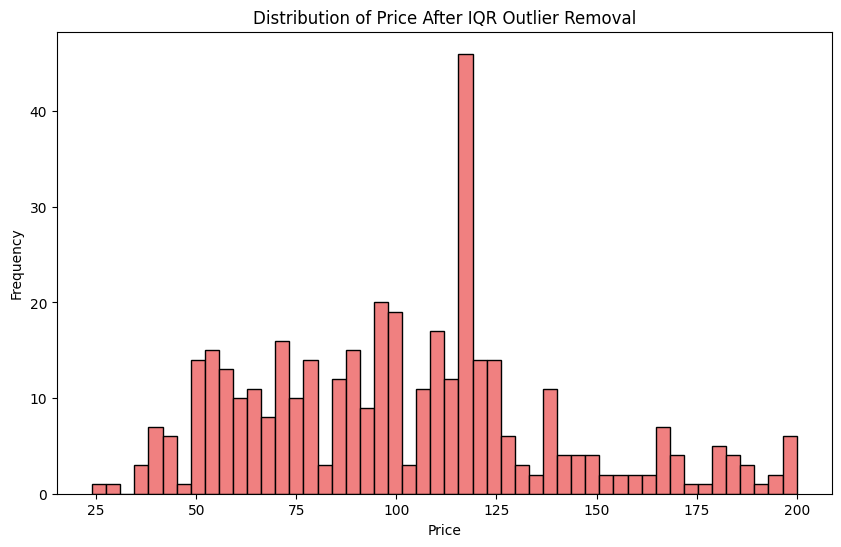

In [204]:
#Visualize the ‘price’ distribution after IQR processing using histplot and briefly analyze the differences between the two distributions.
plt.figure(figsize=(10, 6))
plt.hist(df_cleaned['price'], bins=50, color='lightcoral', edgecolor='black')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Distribution of Price After IQR Outlier Removal')
plt.show()

Without IQR processing, there are quite a few extremely expensive "outliers" in the price distribution, making the overall distribution skewed and scattered, and it's impossible to tell which price range most listings are concentrated in. After IQR processing, those extremely expensive outliers are adjusted to a reasonable range, the price distribution becomes compact all at once, and the common price range of most listings can be clearly seen without being skewed by a few high-priced listings.

Apply Min-Max Scaling for features like 'price' to bring them between 0 and 1. And store the scaled data in the newly created 'price_scaled' column. Print the maximum and minimum values of 'price_scaled'.

In [205]:
#Apply Min-Max Scaling for features like 'price' to bring them between 0 and 1. And store the scaled data in the newly created 'price_scaled' column. Print the maximum and minimum values of 'price_scaled'.
minmax_scaler = MinMaxScaler(feature_range=(0, 1))
df_cleaned['price_scaled'] = minmax_scaler.fit_transform(df_cleaned[['price']])
print(f"Max value of price_scaled: {df_cleaned['price_scaled'].max()}")
print(f"Min value of price_scaled: {df_cleaned['price_scaled'].min()}")

Max value of price_scaled: 1.0
Min value of price_scaled: 0.0


Apply Standardization to other features like ‘number_of_reviews’. And store the processed data in the newly created column 'number_of_reviews_scaled'. Print the mean and standard deviation of 'number_of_reviews_scaled'.

In [206]:
#Apply Standardization to other features like ‘number_of_reviews’. And store the processed data in the newly created column 'number_of_reviews_scaled'. Print the mean and standard deviation of 'number_of_reviews_scaled'.
standard_scaler = StandardScaler()
df_cleaned['number_of_reviews_scaled'] = standard_scaler.fit_transform(df_cleaned[['number_of_reviews']])
print(f"Mean of number_of_reviews_scaled: {df_cleaned['number_of_reviews_scaled'].mean()}")
print(f"Standard deviation of number_of_reviews_scaled: {df_cleaned['number_of_reviews_scaled'].std()}")


Mean of number_of_reviews_scaled: 3.5438540436912727e-17
Standard deviation of number_of_reviews_scaled: 1.0012492197250393


Create a new column 'Price_per_Bedroom' and fill in the relevant data.

In [207]:
#Create a new column 'Price_per_Bedroom' and fill in the relevant data.
df_cleaned['Price_per_Bedroom'] = df_cleaned['price'] / df_cleaned['bedrooms'].replace(0, np.nan)

Create a new column 'description_word_count' and fill in the relevant data. Print the first 5 rows of data for the columns: price, bedrooms, Price_per_Bedroom, description, description_word_count

In [208]:
#Create a new column 'description_word_count' and fill in the relevant data. Print the first 5 rows of data for the columns: price, bedrooms, Price_per_Bedroom, description, description_word_count.
df_cleaned['description_word_count'] = df_cleaned['description'].apply(lambda x: len(str(x).split()))
print(df_cleaned[['price', 'bedrooms', 'Price_per_Bedroom', 'description', 'description_word_count']].head())


        price  bedrooms  Price_per_Bedroom  \
0  117.648101       2.0          58.824051   
1  115.000000       1.0         115.000000   
2   75.000000       0.0                NaN   
3  115.000000       1.0         115.000000   
4   85.000000       1.0          85.000000   

                                         description  description_word_count  
0  The apartment is located in a quiet neighborho...                      27  
1  Cozy, cool little 1BR Apt in the heart Albany'...                      39  
2  Spacious studio with hardwood floors, fully eq...                      69  
3  Large renovated 1 bedroom apartment in convert...                      48  
4  (21 years of age or older ONLY) NON- SMOKING.....                      61  


Split the dataset into features (x) and target variable (y). In this workshop, x is all columns without ‘price’, while y is ‘price’

In [210]:
#Split the dataset into features (x) and target variable (y). In this workshop, x is all columns without ‘price’, while y is ‘price’.
x = df_cleaned.drop(columns=['price'])
y = df_cleaned['price']

Split the data into training (80%) and test (20%) sets.

In [211]:
#Split the data into training (80%) and test (20%) sets.
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

Building a Pipeline with Iris Dataset:

In [212]:
# Importing the iris dataset and dividing it into features and targets.
from sklearn.datasets import load_iris
iris = load_iris()
x = iris.data
y = iris.target

In [213]:
# Divide the training set and testing set in a 7:3 ratio. 
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [214]:
#Create a Pipeline, fill in missing values with the mean, standardize them, and use a logistic regression model with “max_iter=200” for classification. 
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=200))
])

In [215]:
#Train model. 
pipeline.fit(x_train, y_train)

,steps,"[('imputer', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'mean'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [216]:
#Predict and evaluate model.
y_pred = pipeline.predict(x_test)
accuracy = pipeline.score(x_test, y_test)

Model Accuracy: 1.00


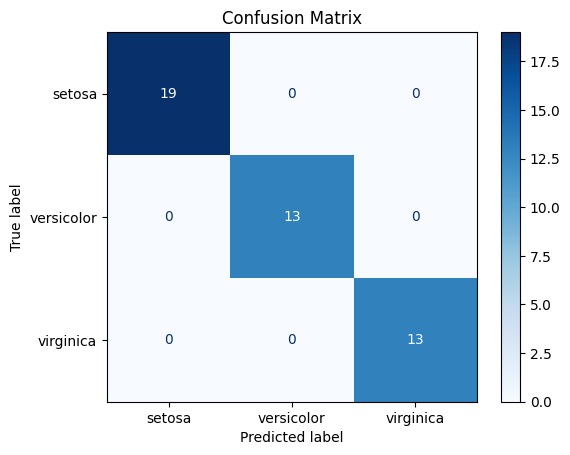

In [217]:
#Output the model accuracy (to 2 decimal places) and visualize the model performance using a confusion matrix.
print(f"Model Accuracy: {accuracy:.2f}")
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()
